In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/._Task08_HepaticVessel
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._labelsTr
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._imagesTr
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._imagesTs
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._dataset.json
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/dataset.json
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/imagesTs/._hepaticvessel_204.nii.gz
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/imagesTs/._hepaticvessel_060.nii.gz
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/imagesTs/hepaticvessel_130.nii
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/imag

In [2]:
import os

# MUST be set before torch is imported — prevents GPU memory fragmentation
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import torch

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    cap   = torch.cuda.get_device_capability(0)
    name  = torch.cuda.get_device_name(0)
    vram  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU     : {name}")
    print(f"Compute : sm_{cap[0]}{cap[1]}")
    print(f"VRAM    : {vram:.1f} GB")
    if cap[0] < 7:
        print("WARNING: GPU too old. Switch to T4 in Session Options.")
    else:
        print("GPU OK.")
else:
    print("No GPU — enable GPU in Kaggle Session Options.")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
Compute : sm_75
VRAM    : 15.6 GB
GPU OK.


In [3]:
!pip install -q monai nibabel tqdm
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.4 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from monai.config import print_config
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import SwinUNETR
from monai.data import DataLoader, Dataset, decollate_batch
from monai.utils import first
from monai.transforms import (
    AsDiscrete,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
    EnsureTyped,
    RandGaussianNoised,
    RandScaleIntensityd,
    RandAdjustContrastd,
    RandZoomd,
)

print_config()
print(f"\nPyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-06-08 02:10:30.888862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780884631.079003      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780884631.133357      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780884631.576519      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780884631.576558      58 computation_placer.cc:1

MONAI version: 1.5.2
Numpy version: 2.4.6
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.4
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#insta

In [5]:
# Dataset location
DATA_ROOT = '/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel'

# Output directory
WORK_DIR = '/kaggle/working/'
os.makedirs(WORK_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(WORK_DIR, 'training_checkpoint.pth')
BEST_MODEL_PATH = os.path.join(WORK_DIR, 'best_metric_model.pth')

# Pretrained weights
PRETRAINED_WEIGHTS = ''

# Training hyperparameters
NUM_CLASSES    = 3
num_samples    = 2
max_iterations = 7000   
eval_num       = 500
warmup_steps   = 0    

# Read dataset.json
with open(os.path.join(DATA_ROOT, 'dataset.json')) as f:
    dataset_info = json.load(f)

print('Dataset :', dataset_info.get('name'))
print('Labels  :', dataset_info.get('labels', {}))

def resolve_path(relative_path):
    rel  = relative_path.lstrip('./')
    full = os.path.join(DATA_ROOT, rel)
    if os.path.exists(full): return full
    if full.endswith('.gz') and os.path.exists(full[:-3]): return full[:-3]
    if not full.endswith('.gz') and os.path.exists(full + '.gz'): return full + '.gz'
    return full

all_files = []
for entry in dataset_info.get('training', []):
    img = resolve_path(entry['image'])
    lbl = resolve_path(entry['label'])
    if os.path.exists(img) and os.path.exists(lbl):
        all_files.append({'image': img, 'label': lbl})

VAL_SIZE    = 20
train_files = all_files[:-VAL_SIZE]
val_files   = all_files[-VAL_SIZE:]

print(f"\nTotal pairs   : {len(all_files)}")
print(f"Training      : {len(train_files)}")
print(f"Validation    : {len(val_files)}")
print(f"\nCheckpoint    : {CHECKPOINT_PATH}")
print(f"Best model    : {BEST_MODEL_PATH}")
print(f"Max steps     : {max_iterations}")
print(f"Eval every    : {eval_num} steps")
print(f"Warmup steps  : {warmup_steps}  (0 = no warmup, second cycle)")

Dataset : HepaticVessel
Labels  : {'0': 'background', '1': 'Vessel', '2': 'Tumour'}

Total pairs   : 303
Training      : 283
Validation    : 20

Checkpoint    : /kaggle/working/training_checkpoint.pth
Best model    : /kaggle/working/best_metric_model.pth
Max steps     : 7000
Eval every    : 500 steps
Warmup steps  : 0  (0 = no warmup, second cycle)


In [6]:
# Visualization only — raw load, no preprocessing
orig_transforms = Compose([
    LoadImaged(keys=['image', 'label'], ensure_channel_first=True),
    EnsureTyped(keys=['image', 'label'], track_meta=False),
])

# Full training pipeline — preprocessing + augmentation
train_transforms = Compose([
    LoadImaged(keys=['image', 'label'], ensure_channel_first=True),

    # HU range [-175, 250]: standard hepatic vessel window
    ScaleIntensityRanged(
        keys=['image'],
        a_min=-175, a_max=250,
        b_min=0.0,  b_max=1.0,
        clip=True,
    ),

    # Remove large black border around patient body
    CropForegroundd(keys=['image', 'label'], source_key='image'),

    # Reorient to RAS standard (Right-Anterior-Superior)
    Orientationd(keys=['image', 'label'], axcodes='RAS'),

    # Resample to 1mm isotropic spacing
    # bilinear for image (smooth), nearest for label (preserves class IDs)
    Spacingd(
        keys=['image', 'label'],
        pixdim=(1.0, 1.0, 1.0),
        mode=('bilinear', 'nearest'),
    ),

    EnsureTyped(keys=['image', 'label'], track_meta=False),

    # Extract 2 random patches of 96x96x96 per volume
    # pos=1, neg=1: 50% patches centered on vessel/tumor, 50% on background
    RandCropByPosNegLabeld(
        keys=['image', 'label'],
        label_key='label',
        spatial_size=(96, 96, 96),
        pos=2, neg=1,
        num_samples=num_samples,
        image_key='image',
        image_threshold=0,
    ),

    # Spatial augmentation
    RandFlipd(keys=['image', 'label'], spatial_axis=[0], prob=0.5),
    RandFlipd(keys=['image', 'label'], spatial_axis=[1], prob=0.5),
    RandFlipd(keys=['image', 'label'], spatial_axis=[2], prob=0.5),
    RandRotate90d(keys=['image', 'label'], prob=0.25, max_k=3),
    RandZoomd(
        keys=['image', 'label'],
        min_zoom=0.9, max_zoom=1.1,
        prob=0.3,
        mode=('trilinear', 'nearest'),
    ),

    # Intensity augmentation — simulates scanner differences between hospitals
    RandShiftIntensityd(keys=['image'], offsets=0.10, prob=0.5),
    RandScaleIntensityd(keys=['image'], factors=0.15, prob=0.5),
    RandAdjustContrastd(keys=['image'], prob=0.3, gamma=(0.7, 1.5)),
    RandGaussianNoised(keys=['image'], prob=0.15, mean=0.0, std=0.01),
])

# Validation: same preprocessing but NO augmentation
# track_meta=True so we can read filename for visualization
val_transforms = Compose([
    LoadImaged(keys=['image', 'label'], ensure_channel_first=True),
    ScaleIntensityRanged(
        keys=['image'],
        a_min=-175, a_max=250,
        b_min=0.0,  b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=['image', 'label'], source_key='image'),
    Orientationd(keys=['image', 'label'], axcodes='RAS'),
    Spacingd(
        keys=['image', 'label'],
        pixdim=(1.0, 1.0, 1.0),
        mode=('bilinear', 'nearest'),
    ),
    EnsureTyped(keys=['image', 'label'], track_meta=True),
])

print("Transforms defined.")
print(f"  Training   : {len(train_transforms.transforms)} transforms (preprocessing + augmentation)")
print(f"  Validation : {len(val_transforms.transforms)} transforms (preprocessing only)")

Transforms defined.
  Training   : 16 transforms (preprocessing + augmentation)
  Validation : 6 transforms (preprocessing only)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
orig_ds     = Dataset(data=train_files, transform=orig_transforms)
orig_loader = DataLoader(orig_ds, batch_size=1, num_workers=2)

train_ds     = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(
    train_ds, batch_size=1, shuffle=True,
    num_workers=0, pin_memory=True
)

val_ds     = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(
    val_ds, batch_size=1,
    num_workers=2, pin_memory=True
)

print(f"Training dataset   : {len(train_ds)} volumes")
print(f"Validation dataset : {len(val_ds)} volumes")
print(f"Patches per epoch  : {len(train_ds) * num_samples} ({len(train_ds)} volumes × {num_samples} patches)")

Training dataset   : 283 volumes
Validation dataset : 20 volumes
Patches per epoch  : 566 (283 volumes × 2 patches)


Original shape    : torch.Size([1, 1, 512, 512, 49])   (batch, channel, H, W, D)
Preprocessed shape: torch.Size([2, 1, 96, 96, 96])  (2 patches, channel, 96, 96, 96)
Visualizing slice 24 of 49


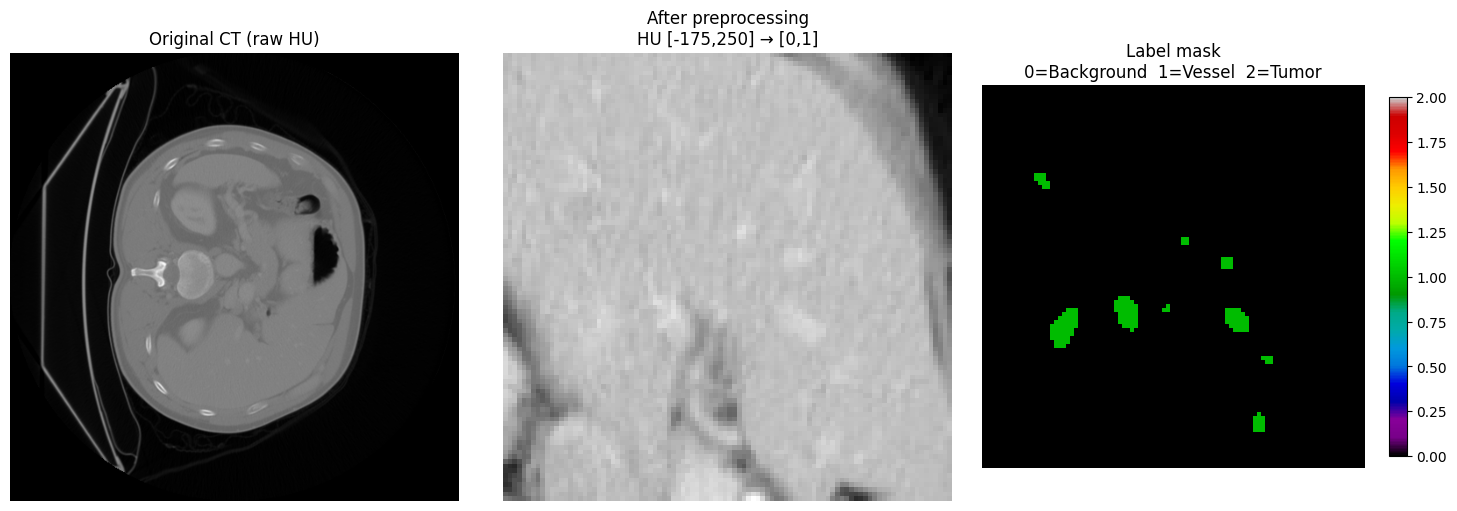

Saved to /kaggle/working/


In [8]:
orig_patient = first(orig_loader)
test_patient = first(train_loader)

print(f"Original shape    : {orig_patient['image'].shape}   (batch, channel, H, W, D)")
print(f"Preprocessed shape: {test_patient['image'].shape}  ({num_samples} patches, channel, 96, 96, 96)")

depth  = orig_patient['image'].shape[-1]
slices = depth // 2
print(f"Visualizing slice {slices} of {depth}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].set_title("Original CT (raw HU)")
axes[0].imshow(orig_patient['image'][0, 0, :, :, slices], cmap='gray')
axes[0].axis('off')

axes[1].set_title("After preprocessing\nHU [-175,250] → [0,1]")
axes[1].imshow(test_patient['image'][0, 0, :, :, slices], cmap='gray')
axes[1].axis('off')

axes[2].set_title("Label mask\n0=Background  1=Vessel  2=Tumor")
im = axes[2].imshow(
    test_patient['label'][0, 0, :, :, slices],
    cmap='nipy_spectral', vmin=0, vmax=2
)
plt.colorbar(im, ax=axes[2], shrink=0.8)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'sample_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {WORK_DIR}")

In [9]:
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Build model
# Note: MONAI 1.4+ removed img_size from __init__ — model infers it from input
model = SwinUNETR(
    in_channels=1,
    out_channels=3,
    feature_size=48,
    use_checkpoint=True,
).to(device)

# Load pretrained weights if available and valid (>100MB file)
weight_valid = (
    PRETRAINED_WEIGHTS != '' and
    os.path.exists(PRETRAINED_WEIGHTS) and
    os.path.getsize(PRETRAINED_WEIGHTS) > 100 * 1024 * 1024
)

if weight_valid:
    size = os.path.getsize(PRETRAINED_WEIGHTS) / 1e6
    print(f"Loading pretrained SwinViT weights ({size:.0f} MB)...")
    weights = torch.load(PRETRAINED_WEIGHTS, map_location=device)
    model.load_from(weights=weights)
    print("Pretrained backbone loaded — model has strong starting point.")
    print("Expected Dice improvement: +0.08 to +0.12 over training from scratch.")
elif PRETRAINED_WEIGHTS != '' and os.path.exists(PRETRAINED_WEIGHTS):
    size = os.path.getsize(PRETRAINED_WEIGHTS) / 1e6
    print(f"Found weights file but only {size:.1f} MB — incomplete download, skipping.")
    if size < 1:
        os.remove(PRETRAINED_WEIGHTS)
        print("Deleted empty/corrupt file.")
    print("Training from scratch.")
else:
    print("No pretrained weights — training from scratch.")
    print("Set PRETRAINED_WEIGHTS path in Cell 3 if you have model_swinvit.pt")

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Approx GPU memory   : {total * 4 / 1e9:.1f} GB (FP32) / ~{total * 2 / 1e9:.1f} GB (FP16)")

Device: cuda
No pretrained weights — training from scratch.
Set PRETRAINED_WEIGHTS path in Cell 3 if you have model_swinvit.pt

Total parameters    : 62,186,757
Trainable parameters: 62,186,757
Approx GPU memory   : ~0.2 GB (FP32) / ~0.1 GB (FP16)


In [11]:
torch.backends.cudnn.benchmark = True

# Simple DiceCELoss — works in all MONAI versions
loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-5,
)

scaler = torch.amp.GradScaler('cuda')

post_label      = AsDiscrete(to_onehot=NUM_CLASSES)
post_pred       = AsDiscrete(argmax=True, to_onehot=NUM_CLASSES)
dice_metric     = DiceMetric(include_background=True, reduction='mean',
                             get_not_nans=False)
dice_metric_cls = DiceMetric(include_background=True, reduction='mean_batch',
                             get_not_nans=False)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=2000,
    eta_min=1e-7
)

Second cycle configured.
  Loss       : DiceCELoss
  LR         : 5e-5 → 1e-7 cosine over 2000 steps
  Max steps  : 7000  (runs 5000 → 7000)


In [12]:
import subprocess, shutil, json

KAGGLE_DATASET_ID = 'vivekkumar30112006/hepatic-checkpoint'

def push_to_kaggle(global_step):
    try:
        push_dir = '/kaggle/working/push_tmp'
        os.makedirs(push_dir, exist_ok=True)

        # Copy files to push folder
        shutil.copy(CHECKPOINT_PATH, os.path.join(push_dir, 'training_checkpoint.pth'))
        if os.path.exists(BEST_MODEL_PATH):
            shutil.copy(BEST_MODEL_PATH, os.path.join(push_dir, 'best_metric_model.pth'))

        # Required metadata
        metadata = {
            "title": "hepatic-checkpoint",
            "id": KAGGLE_DATASET_ID,
            "licenses": [{"name": "CC0-1.0"}]
        }
        with open(os.path.join(push_dir, 'dataset-metadata.json'), 'w') as f:
            json.dump(metadata, f)

        # Push new version
        result = subprocess.run(
            ['kaggle', 'datasets', 'version',
             '-p', push_dir,
             '-m', f'step_{global_step}_dice_{dice_val_best:.4f}',
             '--dir-mode', 'zip'],
            capture_output=True, text=True, timeout=600
        )

        if result.returncode == 0:
            print(f"  Auto-pushed to Kaggle dataset at step {global_step}")
        else:
            print(f"  Push failed: {result.stderr[:200]}")

    except Exception as e:
        print(f"  Auto-push error: {e}")


def save_checkpoint(global_step, dice_val_best, global_step_best,
                    epoch_loss_values, metric_values, class_dice_history):
    torch.save({
        'global_step'          : global_step,
        'model_state_dict'     : model.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict(),
        'scaler_state_dict'    : scaler.state_dict(),
        'scheduler_state_dict' : scheduler.state_dict(),
        'dice_val_best'        : dice_val_best,
        'global_step_best'     : global_step_best,
        'epoch_loss_values'    : epoch_loss_values,
        'metric_values'        : metric_values,
        'class_dice_history'   : class_dice_history,
    }, CHECKPOINT_PATH)

    size = os.path.getsize(CHECKPOINT_PATH) / 1e6
    print(f"  Checkpoint saved locally → {CHECKPOINT_PATH}  ({size:.0f} MB)")

    # Auto push to Kaggle dataset
    push_to_kaggle(global_step)


def load_checkpoint():
    search_paths = [
        '/kaggle/input/datasets/vivekkumar30112006/hepatic-checkpoint/training_checkpoint.pth',
        CHECKPOINT_PATH,
        '/kaggle/input/hepatic-checkpoint/training_checkpoint.pth',
    ]

    found = None
    for path in search_paths:
        if os.path.exists(path) and os.path.getsize(path) > 10000:
            found = path
            break

    if found:
        print(f"Checkpoint found : {found}")
        print(f"File size        : {os.path.getsize(found)/1e6:.0f} MB")
        ckpt = torch.load(found, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scaler.load_state_dict(ckpt['scaler_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        global_step        = ckpt['global_step']
        dice_val_best      = ckpt['dice_val_best']
        global_step_best   = ckpt['global_step_best']
        epoch_loss_values  = ckpt['epoch_loss_values']
        metric_values      = ckpt['metric_values']
        class_dice_history = ckpt.get('class_dice_history', [])
        print(f"Resuming from step {global_step} | Best Dice: {dice_val_best:.4f}")
        return global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history
    else:
        print("No checkpoint found — starting fresh from step 0.")
        return 0, 0.0, 0, [], [], []


print("Checkpoint functions ready.")
print(f"Auto-push target : {KAGGLE_DATASET_ID}")

Checkpoint functions ready.
Auto-push target : vivekkumar30112006/hepatic-checkpoint


In [13]:
def validation(epoch_iterator_val, global_step):
    """Run inference on all validation volumes. Returns mean Dice and per-class Dice."""
    model.eval()
    dice_metric.reset()
    dice_metric_cls.reset()

    with torch.no_grad():
        for batch in epoch_iterator_val:
            val_inputs = batch['image'].to(device)
            val_labels = batch['label'].to(device)

            with torch.amp.autocast('cuda'):
                val_outputs = sliding_window_inference(
                    val_inputs,
                    roi_size=(96, 96, 96),
                    sw_batch_size=2,   # 2 windows in parallel — fits T4 16GB
                    predictor=model,
                    overlap=0.7,       # 70% overlap = smoother predictions at boundaries
                )

            # Convert to one-hot encoding for Dice computation
            val_labels_conv  = [post_label(x) for x in decollate_batch(val_labels)]
            val_outputs_conv = [post_pred(x)  for x in decollate_batch(val_outputs)]

            dice_metric(y_pred=val_outputs_conv, y=val_labels_conv)
            dice_metric_cls(y_pred=val_outputs_conv, y=val_labels_conv)
            epoch_iterator_val.set_description(f"Validate (step {global_step})")

    mean_dice  = dice_metric.aggregate().item()
    class_dice = dice_metric_cls.aggregate()   # shape: (3,) — one per class
    dice_metric.reset()
    dice_metric_cls.reset()

    print(f"  Mean Dice  : {mean_dice:.4f}")
    print(f"  BG         : {class_dice[0]:.4f}  (always near 1.0 — not meaningful)")
    print(f"  Vessel     : {class_dice[1]:.4f}  (most important — thin tubular structures)")
    print(f"  Tumor      : {class_dice[2]:.4f}  (starts 0.0, rises after 1000 steps)")
    return mean_dice, class_dice.tolist()


print("Validation function ready.")

Validation function ready.


In [14]:
def train(global_step, train_loader, dice_val_best, global_step_best,
          epoch_loss_values, metric_values, class_dice_history):
    """One epoch of training. Returns updated training state."""
    model.train()
    epoch_loss = 0
    step = 0

    epoch_iterator = tqdm(
        train_loader,
        desc=f"Training ({global_step}/{max_iterations})",
        dynamic_ncols=True,
    )

    for step, batch in enumerate(epoch_iterator):
        step += 1
        x = batch['image'].to(device)   # shape: (num_samples, 1, 96, 96, 96)
        y = batch['label'].to(device)   # shape: (num_samples, 1, 96, 96, 96)

        # 1. Forward pass with mixed precision
        with torch.amp.autocast('cuda'):
            logit_map = model(x)                    # shape: (num_samples, 3, 96, 96, 96)
            loss = loss_function(logit_map, y)      # scalar

        # 2. Backward pass
        scaler.scale(loss).backward()
        epoch_loss += loss.item()

        # 3. Unscale > clip > optimizer step
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        # 4. Update LR schedule + clear cache
        scheduler.step()
        torch.cuda.empty_cache()

        current_lr = optimizer.param_groups[0]['lr']
        epoch_iterator.set_description(
            f"Training ({global_step}/{max_iterations}) "
            f"loss={loss.item():.5f} lr={current_lr:.2e}"
        )

        # 5. Periodic evaluation and checkpoint save
        if (global_step % eval_num == 0 and global_step != 0) or global_step == max_iterations:
            print(f"\n--- Evaluation at step {global_step} ---")
            val_iter = tqdm(val_loader, desc="Validating...", dynamic_ncols=True)
            dice_val, class_dice = validation(val_iter, global_step)

            epoch_loss_values.append(epoch_loss / step)
            metric_values.append(dice_val)
            class_dice_history.append(class_dice)

            if dice_val > dice_val_best:
                dice_val_best    = dice_val
                global_step_best = global_step
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                print(f"  NEW BEST  Dice: {dice_val_best:.4f}  at step {global_step}")
            else:
                print(f"  No improvement. Best: {dice_val_best:.4f}  Current: {dice_val:.4f}")

            save_checkpoint(
                global_step, dice_val_best, global_step_best,
                epoch_loss_values, metric_values, class_dice_history
            )

        global_step += 1
        if global_step > max_iterations:
            break

    return global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history


print("Training function ready.")

Training function ready.


In [ ]:
# Load checkpoint (resumes if found, starts fresh if not)
global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history = load_checkpoint()

print(f"\nStarting from step  : {global_step}")
print(f"Target steps        : {max_iterations}")
print(f"Steps remaining     : {max_iterations - global_step}")
print(f"Eval/save every     : {eval_num} steps")
print(f"Pretrained weights  : {weight_valid if 'weight_valid' in dir() else False}")
print()

while global_step < max_iterations:
    global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history = train(
        global_step, train_loader, dice_val_best, global_step_best,
        epoch_loss_values, metric_values, class_dice_history
    )

print(f"\n{'='*50}")
print(f"Training complete!")
print(f"Best Dice  : {dice_val_best:.4f}")
print(f"At step    : {global_step_best}")
print(f"{'='*50}")

Checkpoint found : /kaggle/input/datasets/vivekkumar30112006/hepatic-checkpoint/training_checkpoint.pth
File size        : 754 MB
Resuming from step 5000 | Best Dice: 0.6375

Starting from step  : 5000
Target steps        : 7000
Steps remaining     : 2000
Eval/save every     : 500 steps
Pretrained weights  : False



Training (5000/7000) loss=0.56441 lr=1.97e-05:   0%|          | 0/283 [00:17<?, ?it/s]


--- Evaluation at step 5000 ---



Validating...:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/

  Mean Dice  : 0.6297
  BG         : 0.9990  (always near 1.0 — not meaningful)
  Vessel     : 0.5526  (most important — thin tubular structures)
  Tumor      : 0.3374  (starts 0.0, rises after ~1000 steps)
  No improvement. Best: 0.6375  Current: 0.6297
  Checkpoint saved locally → /kaggle/working/training_checkpoint.pth  (754 MB)


Training (5000/7000) loss=0.56441 lr=1.97e-05:   0%|          | 1/283 [52:34<247:07:08, 3154.71s/it]

  Auto-pushed to Kaggle dataset at step 5000 ✅


Training (5500/7000) loss=0.54450 lr=5.80e-06:  77%|███████▋  | 217/283 [22:54<06:24,  5.83s/it]


--- Evaluation at step 5500 ---



Validating...:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/

In [ ]:
if len(epoch_loss_values) == 0:
    print("No data yet")
else:
    x = [eval_num * (i + 1) for i in range(len(epoch_loss_values))]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curve
    axes[0].set_title("Training Loss", fontsize=13)
    axes[0].plot(x, epoch_loss_values, 'b-o', linewidth=2, markersize=5)
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("DiceCE Loss")
    axes[0].grid(True, alpha=0.3)
    if len(epoch_loss_values) > 1:
        axes[0].annotate(f"Final: {epoch_loss_values[-1]:.4f}",
                         xy=(x[-1], epoch_loss_values[-1]),
                         xytext=(-60, 15), textcoords='offset points')

    # Mean Dice curve
    axes[1].set_title("Validation Mean Dice", fontsize=13)
    axes[1].plot(x, metric_values, 'g-o', linewidth=2, markersize=5)
    if dice_val_best > 0:
        axes[1].axhline(y=dice_val_best, color='red', linestyle='--',
                        label=f"Best: {dice_val_best:.4f} @ step {global_step_best}")
        axes[1].legend(fontsize=10)
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Mean Dice Score")
    axes[1].grid(True, alpha=0.3)

    # Per-class Dice curve
    if len(class_dice_history) > 0:
        vessel = [c[1] for c in class_dice_history]
        tumor  = [c[2] for c in class_dice_history]
        x2     = x[:len(vessel)]
        axes[2].set_title("Per-Class Dice (Vessel vs Tumor)", fontsize=13)
        axes[2].plot(x2, vessel, 'r-o', linewidth=2, markersize=5, label=f"Vessel (best: {max(vessel):.4f})")
        axes[2].plot(x2, tumor,  'b-o', linewidth=2, markersize=5, label=f"Tumor  (best: {max(tumor):.4f})")
        axes[2].set_ylim(0, 1)
        axes[2].set_xlabel("Training Step")
        axes[2].legend(fontsize=10)
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {WORK_DIR}training_curves.png")

Loaded best model. Best Dice: 0.6375 at step 4500
Found 113 annotated slices — showing middle one: 153


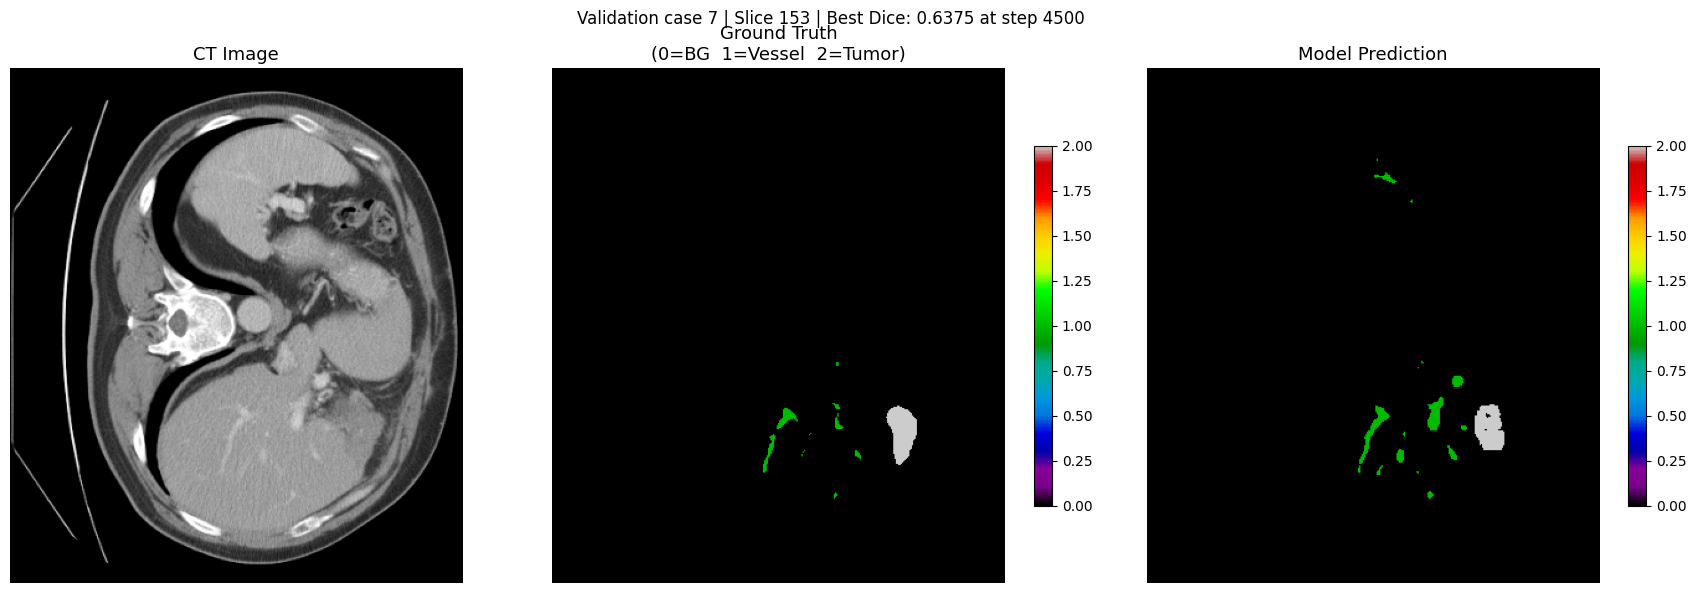

Saved to /kaggle/working/


In [19]:
if not os.path.exists(BEST_MODEL_PATH):
    print("Best model not saved yet — run Cell 12 first.")
else:
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval()
    print(f"Loaded best model. Best Dice: {dice_val_best:.4f} at step {global_step_best}")

    case_num = 7  # change 0–19 to see different validation cases

    with torch.no_grad():
        sample     = val_ds[case_num]
        val_inputs = torch.unsqueeze(sample['image'], 0).to(device)
        val_labels = torch.unsqueeze(sample['label'], 0).to(device)

        with torch.amp.autocast('cuda'):
            val_outputs = sliding_window_inference(
                val_inputs, (96, 96, 96), 2, model, overlap=0.7
            )

    # Find a slice with vessel or tumor annotation
    label_np  = val_labels.cpu().numpy()[0, 0]
    annotated = np.where(label_np.sum(axis=(0, 1)) > 0)[0]
    if len(annotated) > 0:
        vis_slice = int(annotated[len(annotated) // 2])
        print(f"Found {len(annotated)} annotated slices — showing middle one: {vis_slice}")
    else:
        vis_slice = label_np.shape[-1] // 2
        print(f"No annotation found — showing middle slice: {vis_slice}")

    pred = torch.argmax(val_outputs, dim=1).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].set_title("CT Image", fontsize=13)
    axes[0].imshow(val_inputs.cpu().numpy()[0, 0, :, :, vis_slice], cmap='gray')
    axes[0].axis('off')

    axes[1].set_title("Ground Truth\n(0=BG  1=Vessel  2=Tumor)", fontsize=13)
    im = axes[1].imshow(
        val_labels.cpu().numpy()[0, 0, :, :, vis_slice],
        cmap='nipy_spectral', vmin=0, vmax=2
    )
    plt.colorbar(im, ax=axes[1], shrink=0.7)
    axes[1].axis('off')

    axes[2].set_title("Model Prediction", fontsize=13)
    im = axes[2].imshow(
        pred[0, :, :, vis_slice],
        cmap='nipy_spectral', vmin=0, vmax=2
    )
    plt.colorbar(im, ax=axes[2], shrink=0.7)
    axes[2].axis('off')

    plt.suptitle(
        f"Validation case {case_num} | Slice {vis_slice} | "
        f"Best Dice: {dice_val_best:.4f} at step {global_step_best}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(WORK_DIR, f'prediction_case_{case_num}.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Saved to {WORK_DIR}")

In [20]:
print("=" * 60)
print("   EXPERIMENT SUMMARY")
print("=" * 60)
print(f"  Dataset          : MSD Task08 Hepatic Vessel")
print(f"  Train volumes    : {len(train_files)}")
print(f"  Val volumes      : {len(val_files)}")
print()
print(f"  Model            : SwinUNETR")
print(f"  Feature size     : 48  (SwinUNETR-Base)")
print(f"  Parameters       : 62,186,757")
print(f"  Pretrained       : {weight_valid if 'weight_valid' in dir() else False}")
print()
print(f"  Loss             : DiceCELoss (Dice + CrossEntropy)")
print(f"  Optimizer        : AdamW  lr=1e-4  wd=1e-5")
print(f"  LR Schedule      : LinearWarmup({warmup_steps}) + CosineAnnealing → 1e-6")
print(f"  Grad clipping    : max_norm=1.0")
print(f"  Mixed precision  : FP16 (GradScaler)")
print()
print(f"  Input patch      : 96 × 96 × 96 voxels")
print(f"  Patches/volume   : {num_samples}")
print(f"  HU window        : [-175, 250]")
print(f"  Voxel spacing    : 1mm × 1mm × 1mm (isotropic)")
print(f"  Val overlap      : 0.7  (70% sliding window overlap)")
print()
print(f"  Max iterations   : {max_iterations}")
print(f"  Eval every       : {eval_num} steps")
print(f"  Est. train time  : ~14 hours  (2 Kaggle sessions)")
print()
print("-" * 60)
print(f"  Steps completed  : {global_step}")
print(f"  Best Mean Dice   : {dice_val_best:.4f}")
print(f"  Best at step     : {global_step_best}")
if len(class_dice_history) > 0 and len(metric_values) > 0:
    best_idx = metric_values.index(max(metric_values))
    bd       = class_dice_history[best_idx]
    print(f"  Best Vessel Dice : {bd[1]:.4f}")
    print(f"  Best Tumor Dice  : {bd[2]:.4f}")
print(f"  Checkpoint       : {CHECKPOINT_PATH}")
print(f"  Best model       : {BEST_MODEL_PATH}")
print("=" * 60)

   EXPERIMENT SUMMARY
  Dataset          : MSD Task08 Hepatic Vessel
  Train volumes    : 283
  Val volumes      : 20

  Model            : SwinUNETR
  Feature size     : 48  (SwinUNETR-Base)
  Parameters       : 62,186,757
  Pretrained       : False

  Loss             : DiceCELoss (Dice + CrossEntropy)
  Optimizer        : AdamW  lr=1e-4  wd=1e-5
  LR Schedule      : LinearWarmup(500) + CosineAnnealing → 1e-6
  Grad clipping    : max_norm=1.0
  Mixed precision  : FP16 (GradScaler)

  Input patch      : 96 × 96 × 96 voxels
  Patches/volume   : 2
  HU window        : [-175, 250]
  Voxel spacing    : 1mm × 1mm × 1mm (isotropic)
  Val overlap      : 0.7  (70% sliding window overlap)

  Max iterations   : 5000
  Eval every       : 500 steps
  Est. train time  : ~14 hours  (2 Kaggle sessions)

------------------------------------------------------------
  Steps completed  : 5001
  Best Mean Dice   : 0.6375
  Best at step     : 4500
  Best Vessel Dice : 0.5575
  Best Tumor Dice  : 0.3559
  